## Spatially register the two STARmap PLUS sections using rigid transformation with MNNs

In [1]:
import pandas as pd
import numpy as np
import scanpy as sc
import anndata as ad
import umap
import os
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.cm import get_cmap

import INSPIRE

### Load results

In [2]:
res_path = "/gpfs/gibbs/pi/zhao/jz874/project/jiazhao/inspire_revision/tutorials/spatial_alignment/STARmapPLUS"
adata = sc.read_h5ad(res_path + "/adata_inspire.h5ad")

### Register section 1 onto section 2

In [3]:
adata_0 = adata[adata.obs["slice"].values.astype(str)=="1", :]
adata_1 = adata[adata.obs["slice"].values.astype(str)=="0", :]

loc0 = adata_0.obsm["spatial"]
loc1 = adata_1.obsm["spatial"]

latent_0 = adata_0.obsm['latent']
latent_1 = adata_1.obsm['latent']

loc0_registered = INSPIRE.utils.rigid_registration_MNNs(latent_0=latent_0, # latent representations of cells or spots from section 1
                                                        latent_1=latent_1, # latent representations of cells or spots from section 2
                                                        loc0=loc0, # spatial coordinates of cells or spots from section 1
                                                        loc1=loc1, # spatial coordinates of cells or spots from section 2
                                                        k=1, # number of MNNs
                                                        metric='euclidean', # metric used for computing MNNs
                                                        filter_quantile=0.5, # quantile threshold for filtering out low-quality MNNs
                                                       )

### Registration result visualization

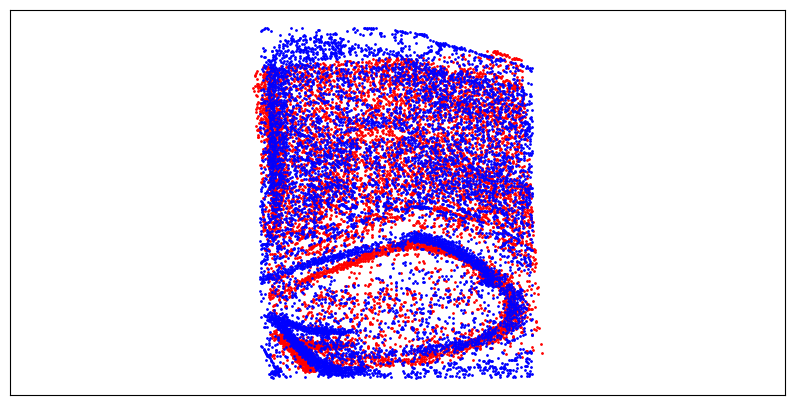

In [4]:
f = plt.figure(figsize=(10,5))
ax = f.add_subplot(1,1,1)
ax.axis('equal')
ax.scatter(loc0_registered[:,0], -loc0_registered[:,1], c="red", s=1)
ax.scatter(loc1[:,0], -loc1[:,1], c="blue", s=1)
ax.tick_params(axis='both',bottom=False, top=False, left=False, right=False, labelleft=False, labelbottom=False, grid_alpha=0)
plt.show()